# Video 5f: Visualizing Fingerprint Bit Environments
Explanation Script:
"Let's visually see what bit 2 looks like in aspirin. We'll highlight the atoms that contribute to this bit."

Bit 2 highlights these atoms (in red):


[10:37:56] DEPRECATION WARNING: please use MorganGenerator


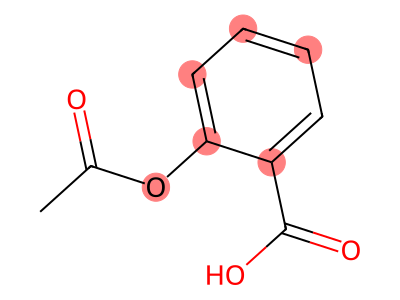

Highlighted atoms: [3, 4, 5, 6, 7, 9]


In [1]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import SimilarityMaps
import matplotlib.pyplot as plt

# Aspirin
smiles = "CC(=O)OC1=CC=CC=C1C(=O)O"
mol = Chem.MolFromSmiles(smiles)

# Generate fingerprint with bit info
bit_info = {}
fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=128, bitInfo=bit_info)

# Function to highlight atoms contributing to a specific bit
def highlight_bit(mol, bit, bit_info):
    if bit not in bit_info:
        print(f"Bit {bit} is 0 in this molecule")
        return None
    
    # Get all atoms involved in this bit
    atoms_to_highlight = set()
    for atom_idx, radius in bit_info[bit]:
        # Get environment atoms
        env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_idx)
        amap = {}
        submol = Chem.PathToSubmol(mol, env, atomMap=amap)
        atoms_to_highlight.update(amap.keys())
    
    return list(atoms_to_highlight)

# Highlight atoms for bit 2
highlight_atoms = highlight_bit(mol, 2, bit_info)
if highlight_atoms:
    img = Draw.MolToImage(mol, size=(400, 300), highlightAtoms=highlight_atoms)
    print("Bit 2 highlights these atoms (in red):")
    display(img)
    print(f"Highlighted atoms: {sorted(highlight_atoms)}")

Explanation Script Continues:
"The red atoms are the ones that make bit 2 = 1. Notice they form two separate fragments: one around the ester group and one around the carboxylic acid. Both fragments have the same connectivity pattern, so they both activate bit 2. This is why fingerprints are so useful - they recognize patterns regardless of where they appear in the molecule."